# First notebook Cells

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


### Load Data

In [2]:
df = pd.read_csv('../data/raw/mock_member_data.csv')

### Preview

In [3]:
df.head() # Preview the first few rows of the dataset

,member_id,age,gender,region,plan_type,chronic_condition_count,engagement_score,ed_visits,ip_admits,monthly_cost,awv_completed
0,M00001,69,Female,Rural,DSNP,3,72.6,1,1,2634.13,0
1,M00002,32,Female,Suburban,Medicare Advantage,0,71.5,0,1,1632.38,1
2,M00003,89,Male,Suburban,Medicaid,2,32.6,0,0,978.36,1
3,M00004,78,Male,Suburban,Medicare Advantage,7,56.0,3,0,2761.83,1
4,M00005,38,Female,Urban,DSNP,2,42.2,0,1,2001.45,1


### Shape

In [4]:
df.shape # Check the number of rows and columns in the dataset

(500, 11)

### Columns

In [5]:
df.columns.tolist() # List all the column names in the dataset to understand the features available

['member_id',
 'age',
 'gender',
 'region',
 'plan_type',
 'chronic_condition_count',
 'engagement_score',
 'ed_visits',
 'ip_admits',
 'monthly_cost',
 'awv_completed']

# Structural Checks

### Data Types

In [6]:
df.info() # Get a concise summary of the DataFrame, including data types and non-null counts

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   member_id                500 non-null    str    
 1   age                      500 non-null    int64  
 2   gender                   500 non-null    str    
 3   region                   500 non-null    str    
 4   plan_type                500 non-null    str    
 5   chronic_condition_count  500 non-null    int64  
 6   engagement_score         500 non-null    float64
 7   ed_visits                500 non-null    int64  
 8   ip_admits                500 non-null    int64  
 9   monthly_cost             500 non-null    float64
 10  awv_completed            500 non-null    int64  
dtypes: float64(2), int64(5), str(4)
memory usage: 43.1 KB


### Summary Stats

In [7]:
df.describe() # Get summary statistics for numerical columns to understand the distribution of the data

,age,chronic_condition_count,engagement_score,ed_visits,ip_admits,monthly_cost,awv_completed
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,52.930000,2.446000,54.820200,0.822000,0.184000,1437.496700,0.696000
std,21.009519,1.542674,17.991338,0.965495,0.422494,655.827185,0.460443
min,18.000000,0.000000,5.000000,0.000000,0.000000,282.990000,0.000000
25%,34.000000,1.000000,43.575000,0.000000,0.000000,926.410000,0.000000
50%,52.000000,2.000000,54.400000,1.000000,0.000000,1334.515000,1.000000
75%,71.000000,3.000000,66.350000,1.000000,0.000000,1831.325000,1.000000
max,89.000000,8.000000,100.000000,4.000000,3.000000,4252.590000,1.000000


### Missing Values 

In [8]:
df.isnull().sum() # Check for missing values in each column

member_id                  0
age                        0
gender                     0
region                     0
plan_type                  0
chronic_condition_count    0
engagement_score           0
ed_visits                  0
ip_admits                  0
monthly_cost               0
awv_completed              0
dtype: int64

### Duplicate member IDs

In [9]:
df["member_id"].duplicated().sum() # Check for duplicate member IDs to ensure data integrity

np.int64(0)

# Categorical review

In [10]:
df["gender"].value_counts() # Check the distribution of the target variable "gender"    

gender
Female    285
Male      215
Name: count, dtype: int64

In [11]:
df["region"].value_counts() # Check the distribution of the target variable "region"    

region
Urban       243
Suburban    149
Rural       108
Name: count, dtype: int64

In [12]:
df["plan_type"].value_counts() # Check the distribution of the target variable "plan_type"    

plan_type
Medicaid              240
Medicare Advantage    195
DSNP                   65
Name: count, dtype: int64

In [13]:
df["awv_completed"].value_counts() # Check the distribution of the target variable "awv_completed"    

awv_completed
1    348
0    152
Name: count, dtype: int64

# Numerical Distribution Review


In [14]:
numeric_cols = [
    "age",
    "chronic_condition_count",
    "engagement_score",
    "ed_visits",
    "ip_admits",
    "monthly_cost"
]

df[numeric_cols].describe()

,age,chronic_condition_count,engagement_score,ed_visits,ip_admits,monthly_cost
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,52.930000,2.446000,54.820200,0.822000,0.184000,1437.496700
std,21.009519,1.542674,17.991338,0.965495,0.422494,655.827185
min,18.000000,0.000000,5.000000,0.000000,0.000000,282.990000
25%,34.000000,1.000000,43.575000,0.000000,0.000000,926.410000
50%,52.000000,2.000000,54.400000,1.000000,0.000000,1334.515000
75%,71.000000,3.000000,66.350000,1.000000,0.000000,1831.325000
max,89.000000,8.000000,100.000000,4.000000,3.000000,4252.590000


In [15]:
df[numeric_cols].min() # Check the minimum values for numeric columns to identify any potential data entry errors (e.g., negative values)

age                         18.00
chronic_condition_count      0.00
engagement_score             5.00
ed_visits                    0.00
ip_admits                    0.00
monthly_cost               282.99
dtype: float64

In [16]:
df[numeric_cols].max() # Check the maximum values for numeric columns to identify any potential outliers or data entry errors (e.g., extremely high values)


age                          89.00
chronic_condition_count       8.00
engagement_score            100.00
ed_visits                     4.00
ip_admits                     3.00
monthly_cost               4252.59
dtype: float64

# Create First Charts

### Age Distribution

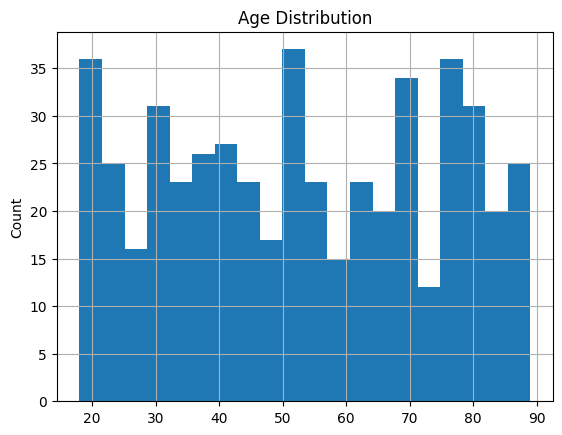

In [17]:
df["age"].hist(bins=20) # Visualize the distribution of the "age" column to identify any skewness or outliers
plt.title("Age Distribution")
plt.xlabel
plt.ylabel("Count")
plt.show()

### Monthly Cost Distribution

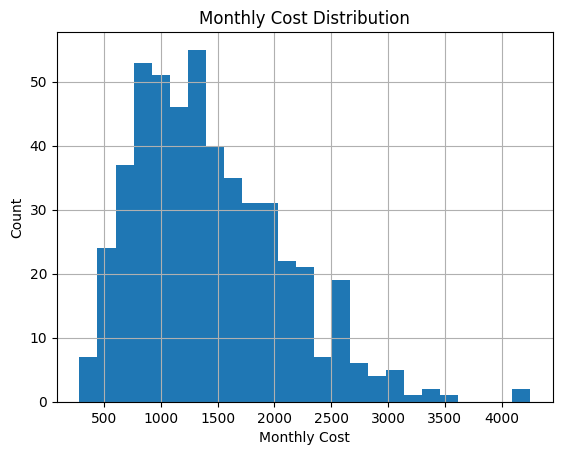

In [18]:
df["monthly_cost"].hist(bins=25) # Visualize the distribution of the "monthly_cost" column to identify any skewness or outliers
plt.title("Monthly Cost Distribution")
plt.xlabel("Monthly Cost")
plt.ylabel("Count")
plt.show()

### Plan Type Counts

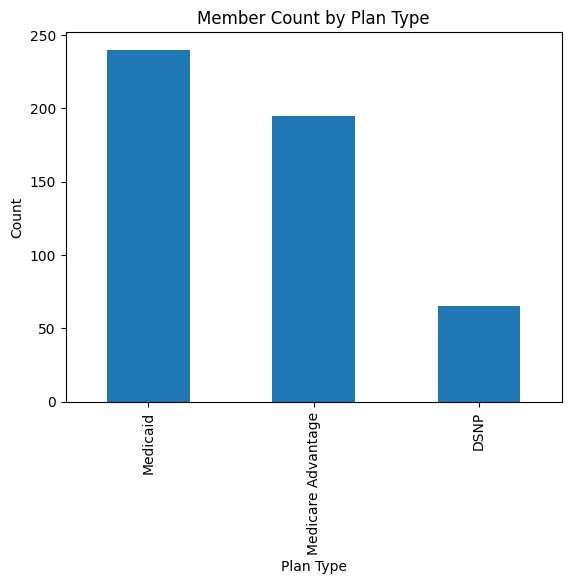

In [19]:
df["plan_type"].value_counts().plot(kind="bar")
plt.title("Member Count by Plan Type")
plt.xlabel("Plan Type")
plt.ylabel("Count")
plt.show()

### AWV completion counts

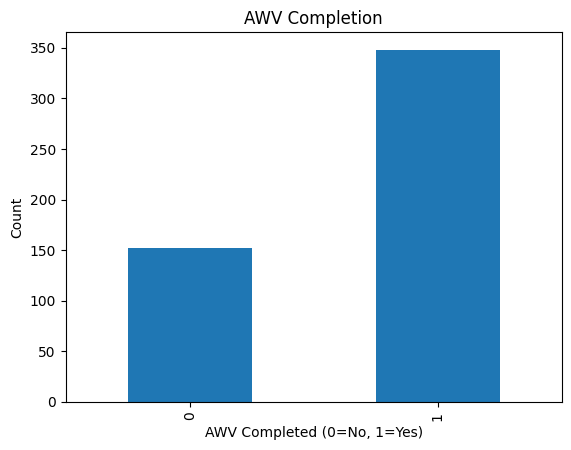

In [20]:
df["awv_completed"].value_counts().sort_index().plot(kind="bar")
plt.title("AWV Completion")
plt.xlabel("AWV Completed (0=No, 1=Yes)")
plt.ylabel("Count")
plt.show()

### Chronic Condtion Count Distribution

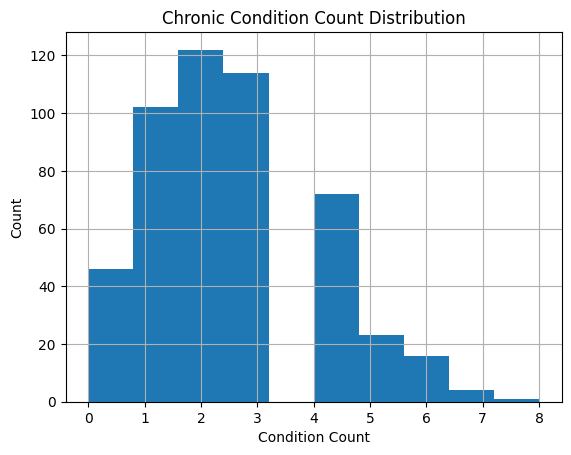

In [21]:
df["chronic_condition_count"].hist(bins=10)
plt.title("Chronic Condition Count Distribution")
plt.xlabel("Condition Count")
plt.ylabel("Count")
plt.show()

# Grouped EDA

### Average Monthly Cost By Plan Type

In [22]:
df.groupby("plan_type")["monthly_cost"].mean().sort_values()

plan_type
Medicaid              1271.701167
Medicare Advantage    1516.051487
DSNP                  1814.000462
Name: monthly_cost, dtype: float64

### Average ED Visits By Chronic Condition Count

In [23]:
df.groupby("chronic_condition_count")["ed_visits"].mean()

chronic_condition_count
0    0.369565
1    0.441176
2    0.622951
3    1.008772
4    1.083333
5    1.652174
6    1.687500
7    2.750000
8    4.000000
Name: ed_visits, dtype: float64

### AWV Completion Rate By Plan Type

In [24]:
df.groupby("plan_type")["awv_completed"].mean().sort_values

<bound method Series.sort_values of plan_type
DSNP                  0.692308
Medicaid              0.712500
Medicare Advantage    0.676923
Name: awv_completed, dtype: float64>

### AWV Completion Rate By Engagement Quartile

In [25]:
df["engagement_group"] = pd.qcut(df["engagement_score"], q=4, labels=["Q1", "Q2", "Q3", "Q4"])
df.groupby("engagement_group")["awv_completed"].mean().sort_values()


engagement_group
Q1    0.520000
Q2    0.692913
Q3    0.756098
Q4    0.816000
Name: awv_completed, dtype: float64

### Average Monthly Cost By AWV Completion

In [26]:
df.groupby("awv_completed")["monthly_cost"].mean()

awv_completed
0    1399.649408
1    1454.027701
Name: monthly_cost, dtype: float64

# Create Age Bands

In [27]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[17, 34, 49, 64, 79, 100],
    labels=["18-34", "35-49", "50-64", "65-79", "80+"]
)

In [28]:
df["age_group"].value_counts().sort_index()

age_group
18-34    126
35-49     98
50-64     98
65-79    119
80+       59
Name: count, dtype: int64

In [29]:
df.groupby("age_group")["monthly_cost"].mean()

age_group
18-34    1042.863889
35-49    1143.811429
50-64    1407.046939
65-79    1881.608319
80+      1922.915085
Name: monthly_cost, dtype: float64

In [30]:
df.groupby("age_group")["awv_completed"].mean()

age_group
18-34    0.611111
35-49    0.673469
50-64    0.744898
65-79    0.680672
80+      0.864407
Name: awv_completed, dtype: float64

# Relationship Checks

In [31]:
corr_cols = [
    "age",
    "chronic_condition_count",
    "engagement_score",
    "ed_visits",
    "ip_admits",
    "monthly_cost",
    "awv_completed"
]

df[corr_cols].corr()

,age,chronic_condition_count,engagement_score,ed_visits,ip_admits,monthly_cost,awv_completed
age,1.000000,0.529438,-0.043838,0.190849,0.196066,0.525871,0.129757
chronic_condition_count,0.529438,1.000000,0.013336,0.416685,0.135189,0.713348,0.067124
engagement_score,-0.043838,0.013336,1.000000,-0.038568,0.015434,-0.027143,0.249768
ed_visits,0.190849,0.416685,-0.038568,1.000000,0.001847,0.523278,-0.040823
ip_admits,0.196066,0.135189,0.015434,0.001847,1.000000,0.664239,0.030575
monthly_cost,0.525871,0.713348,-0.027143,0.523278,0.664239,1.000000,0.038178
awv_completed,0.129757,0.067124,0.249768,-0.040823,0.030575,0.038178,1.000000


# Write Down Findings

## Initial Findings

1. Monthly cost appears to increase with chronic condition count, inpatient admissions, and age.
2. Engagement score shows a positive relationship with AWV completion, but the strength of that relationship appears modest.
3. Most members in this synthetic dataset are AWV-compliant. Since ED visits and inpatient admits are major cost drivers, it may be useful to examine whether AWV completion is associated with lower utilization.
4. Higher engagement scores may be associated with lower cost and lower utilization, but this should not be interpreted as a causal relationship without further analysis.
5. Average monthly cost is higher among AWV-compliant members than non-compliant members. This may reflect differences in age, disease burden, or other confounding factors rather than the direct effect of AWV completion itself.

In [32]:
df.to_csv("../data/processed/member_eda_ready.csv", index = False)